In [1]:
!pip install mlxtend

In [2]:
import pandas as pd
from mlxtend.frequent_patterns import apriori as mlxtend_apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
random_seed=42

In [4]:
aisles_original = pd.read_csv('aisles.csv')
departments_original = pd.read_csv('departments.csv')
order_products_original = pd.read_csv('order_products.csv')
orders_original = pd.read_csv('orders.csv')
products_original = pd.read_csv('products.csv')

In [5]:
aisles = aisles_original.copy()
departments = departments_original.copy()
order_products = order_products_original.copy()
orders = orders_original.copy()
products = products_original.copy()

# **Head dataframe**

In [6]:
aisles_original.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [7]:
departments_original.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [8]:
orders_original.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


In [9]:
orders_original_sorted = orders_original.sort_values(by='order_id')
orders_original_sorted.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
1868044,1,112108,4,4,10,9.0
3355525,2,202279,3,5,9,8.0
3417191,3,205970,16,5,17,12.0
2958007,4,178520,36,1,9,7.0
2593373,5,156122,42,6,16,9.0


In [10]:
order_products_original.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [11]:
products_original.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


# **Task 1a**

In [12]:
orders = orders[['order_id', 'user_id', 'order_dow', 'order_hour_of_day']]
order_products = order_products[['order_id', 'product_id']]
products = products[['product_id', 'product_name', 'aisle_id']]

In [13]:
#verify if there is some null value so that I can delete them
orders.isnull().sum()

order_id             0
user_id              0
order_dow            0
order_hour_of_day    0
dtype: int64

In [14]:
# sample 60% of orders (safe starting point)
orders_sample = orders.sample(frac=0.6, random_state=random_seed)

# keep only related order_products
order_products = order_products[
    order_products['order_id'].isin(orders_sample['order_id'])
]

# replace orders
orders = orders_sample

In [15]:
print("Orders original:", len(orders_original))
print("Order_products original:", len(order_products_original))

Orders original: 3421083
Order_products original: 33819106


In [16]:
print("Orders:", len(orders))
print("Order_products:", len(order_products))

Orders: 2052650
Order_products: 20287347


# **Task 1b**

In [17]:
# Merge order_products with products to get product names
df = order_products.merge(products[['product_id', 'product_name', 'aisle_id']],
                          on='product_id', how='left')

print(f"Rows after merge: {len(df):,}")
print(f"Missing product names: {df['product_name'].isna().sum()}")

Rows after merge: 20,287,347
Missing product names: 0


In [18]:
# Remove very rare products (appear in fewer than MIN_ITEM_FREQ orders)
MIN_ITEM_FREQ = 10

item_freq = df.groupby('product_name')['order_id'].nunique()
frequent_items = item_freq[item_freq >= MIN_ITEM_FREQ].index

df = df[df['product_name'].isin(frequent_items)]

print(f"Products before frequency filter : {item_freq.shape[0]:,}")
print(f"Products after  frequency filter : {len(frequent_items):,}")
print(f"Rows kept: {len(df):,}")

Products before frequency filter : 49,531
Products after  frequency filter : 38,416
Rows kept: 20,230,978


In [19]:
# Group by order_id: each order becomes a list of product names (a "transaction")

transactions_series = (
    df.groupby('order_id')['product_name']
      .apply(lambda x: sorted(set(x)))
)

# Remove single-item baskets: they cannot produce association rules
before = len(transactions_series)
transactions_series = transactions_series[transactions_series.apply(len) > 1]
after  = len(transactions_series)

print(f"Orders before removing single-item baskets : {before:,}")
print(f"Orders after                               : {after:,}")
print(f"Dropped                                    : {before - after:,}")

Orders before removing single-item baskets : 2,007,310
Orders after                               : 1,908,669
Dropped                                    : 98,641


In [20]:
# Convert to plain list-of-lists (format expected by mlxtend)
transactions = transactions_series.tolist()

print(f"\nFinal transactions  : {len(transactions):,}")
print(f"Mean basket size     : {sum(len(t) for t in transactions) / len(transactions):.2f}")
print(f"Min basket size     : {min(len(t) for t in transactions)}")
print(f"Max basket size     : {max(len(t) for t in transactions)}")


Final transactions  : 1,908,669
Mean basket size     : 10.55
Min basket size     : 2
Max basket size     : 127


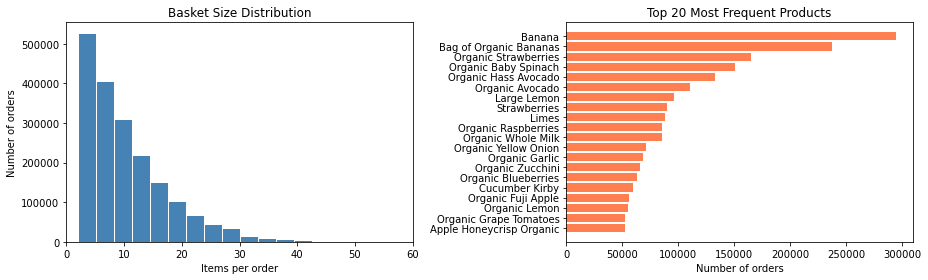

In [21]:
basket_sizes = [len(t) for t in transactions]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Basket size distribution
axes[0].hist(basket_sizes, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Basket Size Distribution')
axes[0].set_xlabel('Items per order')
axes[0].set_ylabel('Number of orders')
axes[0].set_xlim(0, 60)

# Top 20 most frequent products
top20 = item_freq[item_freq.index.isin(frequent_items)].nlargest(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='coral')
axes[1].set_title('Top 20 Most Frequent Products')
axes[1].set_xlabel('Number of orders')

plt.tight_layout()
plt.savefig('task1b_summary.png', dpi=150)
plt.show()

# **Task 2a**

In [22]:
# Rebuild transactions using aisles for mining
df_aisle = order_products.merge(products[['product_id', 'aisle_id']], 
                                 on='product_id', how='left')
df_aisle = df_aisle.merge(aisles, on='aisle_id', how='left')

# Sample 10% of orders to reduce memory usage for mining
orders_for_mining = orders.sample(frac=0.1, random_state=42)
df_aisle = df_aisle[df_aisle['order_id'].isin(orders_for_mining['order_id'])]

transactions_series = (
    df_aisle.groupby('order_id')['aisle']
            .apply(lambda x: sorted(set(x)))
)
transactions_series = transactions_series[transactions_series.apply(len) > 1]
transactions = transactions_series.tolist()

print(f"Transactions: {len(transactions):,}")
print(f"First transaction: {transactions[0]}")

Transactions: 188,269
First transaction: ['fresh herbs', 'fresh vegetables', 'grains rice dried goods', 'hot dogs bacon sausage', 'nuts seeds dried fruit', 'packaged vegetables fruits', 'tea']


In [23]:
# Convert transactions to mlxtend format
te = TransactionEncoder()
te_array = te.fit_transform(transactions, sparse=True)
te = TransactionEncoder()
te_array = te.fit_transform(transactions, sparse=True)

df_encoded = pd.DataFrame.sparse.from_spmatrix(
    te_array,
    columns=te.columns_
)

print(f"Transaction matrix shape: {df_encoded.shape}")

Transaction matrix shape: (188269, 134)


In [24]:
# Varying min_support,min_confidence=0.3
support_values = [0.01, 0.02, 0.05, 0.10]

results = []
for sup in support_values:
    freq_items = mlxtend_apriori(df_encoded, min_support=sup, use_colnames=True,low_memory=True)
    rules = association_rules(freq_items, metric="confidence", min_threshold=0.3)
    results.append({
        'min_support': sup,
        'n_frequent_itemsets': len(freq_items),
        'n_rules': len(rules)
    })
    print(f"min_support={sup:.2f} → {len(freq_items):,} frequent itemsets, {len(rules):,} rules")

results_df = pd.DataFrame(results)

min_support=0.01 → 3,284 frequent itemsets, 7,845 rules
min_support=0.02 → 935 frequent itemsets, 1,877 rules
min_support=0.05 → 177 frequent itemsets, 266 rules
min_support=0.10 → 42 frequent itemsets, 50 rules


In [25]:
# Varying min_confidence values, min_support=0.02
freq_items_fixed = mlxtend_apriori(df_encoded, min_support=0.02, use_colnames=True,low_memory=True)

confidence_values = [0.1, 0.2, 0.3, 0.5, 0.7]

conf_results = []
for conf in confidence_values:
    rules = association_rules(freq_items_fixed, metric="confidence", min_threshold=conf)
    conf_results.append({
        'min_confidence': conf,
        'n_rules': len(rules)
    })
    print(f"min_confidence={conf:.1f} → {len(rules):,} rules")

conf_results_df = pd.DataFrame(conf_results)

min_confidence=0.1 → 3,739 rules
min_confidence=0.2 → 2,609 rules
min_confidence=0.3 → 1,877 rules
min_confidence=0.5 → 1,010 rules
min_confidence=0.7 → 446 rules


In [26]:
#Final rule mining with chosen thresholds
MIN_SUPPORT    = 0.02
MIN_CONFIDENCE = 0.25

freq_items_final = mlxtend_apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True, low_memory=True)
rules_final = association_rules(freq_items_final, metric="confidence", min_threshold=MIN_CONFIDENCE)

# Add lift filter: keep only rules where lift > 1 (non-trivial relationships)
rules_final = rules_final[rules_final['lift'] > 1]
rules_final = rules_final.sort_values('lift', ascending=False)

print(f"\nFinal rules (support≥{MIN_SUPPORT}, confidence≥{MIN_CONFIDENCE}, lift>1): {len(rules_final)}")
print(rules_final[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())


Final rules (support≥0.02, confidence≥0.25, lift>1): 2175
                                       antecedents                                        consequents   support  confidence      lift
112                                    (dry pasta)                                      (pasta sauce)  0.020800    0.277534  4.172068
113                                  (pasta sauce)                                        (dry pasta)  0.020800    0.312680  4.172068
2188       (yogurt, fresh fruits, packaged cheese)                 (milk, packaged vegetables fruits)  0.022670    0.310626  2.659567
1975                (fresh vegetables, lunch meat)      (packaged cheese, packaged vegetables fruits)  0.020704    0.320401  2.625532
2189         (packaged cheese, milk, fresh fruits)               (yogurt, packaged vegetables fruits)  0.022670    0.358084  2.603540
543   (chips pretzels, packaged vegetables fruits)                             (fresh dips tapenades)  0.020577    0.266657  2.557611
212

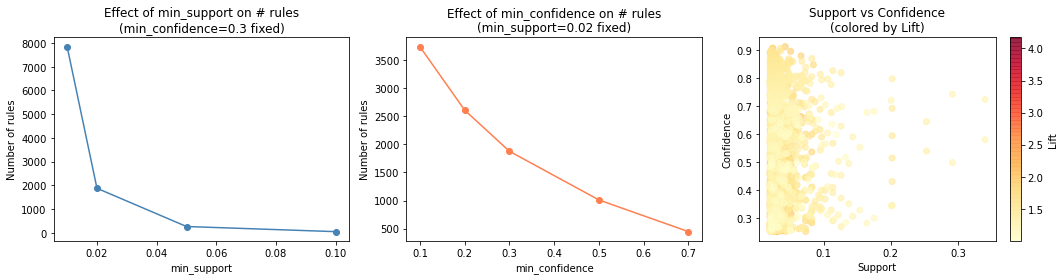

In [27]:
#Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Effect of min_support on number of rules
axes[0].plot(results_df['min_support'], results_df['n_rules'], marker='o', color='steelblue')
axes[0].set_title('Effect of min_support on # rules\n(min_confidence=0.3 fixed)')
axes[0].set_xlabel('min_support')
axes[0].set_ylabel('Number of rules')

# 2. Effect of min_confidence on number of rules
axes[1].plot(conf_results_df['min_confidence'], conf_results_df['n_rules'], marker='o', color='coral')
axes[1].set_title('Effect of min_confidence on # rules\n(min_support=0.02 fixed)')
axes[1].set_xlabel('min_confidence')
axes[1].set_ylabel('Number of rules')

# 3. Support vs Confidence scatter, colored by lift
sc = axes[2].scatter(rules_final['support'], rules_final['confidence'],
                     c=rules_final['lift'], cmap='YlOrRd', alpha=0.6)
plt.colorbar(sc, ax=axes[2], label='Lift')
axes[2].set_title('Support vs Confidence\n(colored by Lift)')
axes[2].set_xlabel('Support')
axes[2].set_ylabel('Confidence')

plt.tight_layout()
plt.savefig('task2a_summary.png', dpi=150)
plt.show()

# **Task 2b**

In [28]:
# Filter rules involving only aisles (no timing items)

product_rules = rules_final.copy()

# Display the top 10 rules by lift
print("=== TOP 10 RULES BY LIFT ===")
print(product_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())

=== TOP 10 RULES BY LIFT ===
                                       antecedents                                        consequents   support  confidence      lift
112                                    (dry pasta)                                      (pasta sauce)  0.020800    0.277534  4.172068
113                                  (pasta sauce)                                        (dry pasta)  0.020800    0.312680  4.172068
2188       (yogurt, fresh fruits, packaged cheese)                 (milk, packaged vegetables fruits)  0.022670    0.310626  2.659567
1975                (fresh vegetables, lunch meat)      (packaged cheese, packaged vegetables fruits)  0.020704    0.320401  2.625532
2189         (packaged cheese, milk, fresh fruits)               (yogurt, packaged vegetables fruits)  0.022670    0.358084  2.603540
543   (chips pretzels, packaged vegetables fruits)                             (fresh dips tapenades)  0.020577    0.266657  2.557611
2125       (yogurt, fresh fruits,

In [29]:
# Add order_dow e order_hour_of_day as item in transactions

df_timing = df_aisle.merge(orders[['order_id', 'order_dow', 'order_hour_of_day']],
                            on='order_id', how='left')

# Convert day of week to readable name
df_timing['dow_item'] = df_timing['order_dow'].map({
    0: 'day_Sunday',
    1: 'day_Monday',
    2: 'day_Tuesday',
    3: 'day_Wednesday',
    4: 'day_Thursday',
    5: 'day_Friday',
    6: 'day_Saturday'
})

# Group hours into time slots
df_timing['hour_item'] = df_timing['order_hour_of_day'].apply(
    lambda h: 'time_Morning'   if 6  <= h < 12
         else 'time_Afternoon' if 12 <= h < 18
         else 'time_Evening'   if 18 <= h < 22
         else 'time_Night'
)

print("Timing items added:")
print(df_timing[['order_id', 'dow_item', 'hour_item']].drop_duplicates().head(5))

Timing items added:
    order_id       dow_item       hour_item
0          8   day_Thursday    time_Morning
1         31   day_Saturday  time_Afternoon
11        57   day_Saturday    time_Morning
18        67  day_Wednesday  time_Afternoon
26        76     day_Monday    time_Evening


In [30]:
# Purchase timing
transactions_timing = (
    df_timing.groupby('order_id')
             .apply(lambda x: sorted(set(
                 list(x['aisle']) +
                 [x['dow_item'].iloc[0]] +
                 [x['hour_item'].iloc[0]]
             )))
)
transactions_timing = transactions_timing[transactions_timing.apply(len) > 1].tolist()

print(f"Timing transactions: {len(transactions_timing):,}")
print(f"First transaction: {transactions_timing[0]}")

Timing transactions: 200,789
First transaction: ['buns rolls', 'day_Thursday', 'time_Morning']


In [31]:
# Mine association rules on timing transactions
te_timing = TransactionEncoder()
te_array_timing = te_timing.fit_transform(transactions_timing, sparse=True)

df_encoded_timing = pd.DataFrame.sparse.from_spmatrix(
    te_array_timing,
    columns=te_timing.columns_
)

freq_items_timing = mlxtend_apriori(df_encoded_timing,
                                    min_support=MIN_SUPPORT,
                                    use_colnames=True,low_memory=True)
rules_timing = association_rules(freq_items_timing,
                                 metric="confidence",
                                 min_threshold=MIN_CONFIDENCE)
rules_timing = rules_timing[rules_timing['lift'] > 1]
rules_timing = rules_timing.sort_values('lift', ascending=False)

print(f"Total timing rules: {len(rules_timing)}")


Total timing rules: 3122


In [32]:
# Filter rules involving timing items(at least one item starting with 'day_' or 'time_' in the antecedent or consequent)
def contains_timing(itemset):
    return any(str(item).startswith('day_') or str(item).startswith('time_')
               for item in itemset)

timing_rules = rules_timing[
    rules_timing['antecedents'].apply(contains_timing) |
    rules_timing['consequents'].apply(contains_timing)
]

print(f"Timing rules: {len(timing_rules)}")
print("\n=== TOP 10 TIMING RULES BY LIFT ===")
print(timing_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())

Timing rules: 1205

=== TOP 10 TIMING RULES BY LIFT ===
                                          antecedents                                       consequents   support  confidence      lift
3304       (yogurt, fresh vegetables, time_Afternoon)                   (packaged cheese, fresh fruits)  0.022013    0.329777  2.137296
2397                      (fresh herbs, time_Morning)                  (fresh vegetables, fresh fruits)  0.020524    0.680819  2.135120
3303  (packaged cheese, fresh fruits, time_Afternoon)                        (yogurt, fresh vegetables)  0.022013    0.303613  2.107085
2391                                    (fresh herbs)  (fresh vegetables, fresh fruits, time_Afternoon)  0.029728    0.316238  2.093199
2952                    (fresh herbs, time_Afternoon)    (fresh vegetables, packaged vegetables fruits)  0.022661    0.494082  2.080885
2396                      (fresh fruits, fresh herbs)                  (fresh vegetables, time_Morning)  0.020524    0.290662  2

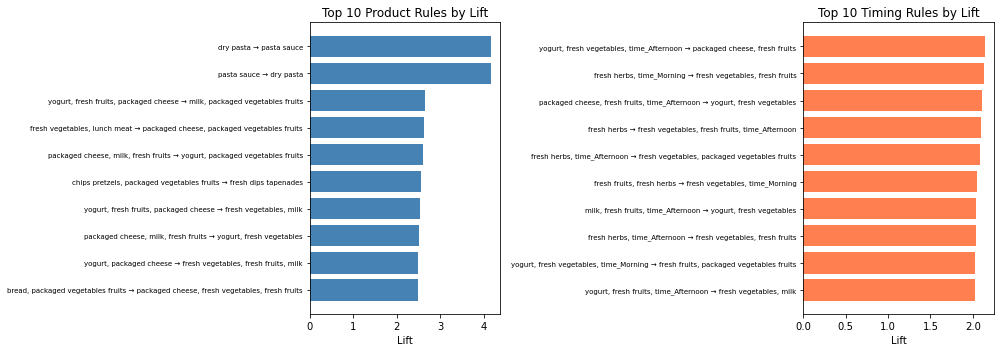

In [33]:
#Visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Top 10 product rules per lift
top10_product = product_rules.head(10).copy()
top10_product['rule'] = (top10_product['antecedents'].apply(lambda x: ', '.join(list(x))) +
                         ' → ' +
                         top10_product['consequents'].apply(lambda x: ', '.join(list(x))))
axes[0].barh(top10_product['rule'][::-1], top10_product['lift'][::-1], color='steelblue')
axes[0].set_title('Top 10 Product Rules by Lift')
axes[0].set_xlabel('Lift')
plt.setp(axes[0].get_yticklabels(), fontsize=7)

# 2. Top 10 timing rules per lift
top10_timing = timing_rules.head(10).copy()
top10_timing['rule'] = (top10_timing['antecedents'].apply(lambda x: ', '.join(list(x))) +
                        ' → ' +
                        top10_timing['consequents'].apply(lambda x: ', '.join(list(x))))
axes[1].barh(top10_timing['rule'][::-1], top10_timing['lift'][::-1], color='coral')
axes[1].set_title('Top 10 Timing Rules by Lift')
axes[1].set_xlabel('Lift')
plt.setp(axes[1].get_yticklabels(), fontsize=7)

plt.tight_layout()
plt.savefig('task2b_summary.png', dpi=150)
plt.show()